<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Validation Legacy 2: Solar Precision
---

This notebook validates TPeanuts' solar-neutrino production probabilities against the reference implementation in legacy Peanuts. Seven solar fusion sources are compared in both the flavour basis (`solar_probability_state`) and the mass-eigenstate basis (`solar_probability_mass`), using the B16 AGSS09 Standard Solar Model and NuFIT 5.2 oscillation parameters.

## Table of Contents

| § | Title |
|---|-------|
| [0](#0.-Theory-Background) | **Theory Background** — MSW Hamiltonian, B16 solar model, source profiles, validation strategy |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** — notebook paths, physical parameters |
| [3](#3.-Solar-Probability-Validation) | **Solar Probability Validation** — seven sources vs legacy Peanuts |
| [4](#4.-Precision-Mode-Diagnostic) | **Precision Mode Diagnostic** — full vs legacy precision comparison |
| [5](#5.-Solar-Mass-Basis-Probability-Comparison) | **Solar Mass-Basis Probability Comparison** — mass-eigenstate populations |
| [6](#6.-Export-Results) | **Export Results** |
| [7](#7.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 The MSW Hamiltonian for Solar Neutrinos

Solar neutrino propagation is described by the Mikheyev–Smirnov–Wolfenstein (MSW) formalism *(Wolfenstein 1978; Mikheyev & Smirnov 1985)*. In the flavour basis, the charged-current potential from coherent forward scattering of $\nu_e$ on solar electrons is added to the vacuum kinetic term:

$$H = U\,\frac{\mathrm{diag}(0,\,\Delta m^2_{21},\,\Delta m^2_{31})}{2E}\,U^\dagger + \mathrm{diag}(V_{cc}(r),\,0,\,0),$$

where the charged-current potential is

$$V_{cc}(r) = \sqrt{2}\,G_F\,n_e(r),$$

$G_F$ is the Fermi constant, and $n_e(r)$ is the local electron number density at solar radius $r$. The neutral-current term is flavour-universal and cancels from the oscillation probability.
- At high energies or densities the matter term dominates, producing nearly complete flavour conversion via the MSW resonance.
- At low energies the vacuum kinetic term dominates.

---

### 0.2 The B16 Standard Solar Model and Source Profiles

The density and fusion-source profiles come from the **B16 Standard Solar Model** with AGSS09 photospheric abundances *(Vinyoles et al. 2017)*. The key inputs are:

- **Electron density profile** $n_e(r)$: tabulated from the solar centre to the surface ($r \in [0,\,1]\,R_\odot$).
- **Fusion source profiles** $f_s(r)$: fractional production weight per source $s$ satisfying $\int_0^{R_\odot} f_s(r)\,\mathrm{d}r = 1$.
- **Solar flux normalisations**: total fluxes for pp, $^7$Be, $^8$B, hep, $^{13}$N, $^{15}$O, and $^{17}$F.

These are the same numerical tables used by legacy Peanuts, ensuring a like-for-like comparison.

---

### 0.3 Solar Production Probability

The function `solar_probability_state` computes the probability that a neutrino produced with the source-weighted radial profile exits the Sun with final flavour $\nu_\beta$:

$$P(\nu_e^\odot \to \nu_\beta;\ E) = \int_0^{R_\odot} f_s(r)\,P(\nu_e \to \nu_\beta;\ r,\, E)\,\mathrm{d}r,$$

where the inner probability is the solution to the MSW evolution from production point $r$ to the solar surface. The **mass-basis variant** `solar_probability_mass` returns the incoherent mass-eigenstate populations $P_i^\odot(E)$, which serve as input weights for the Earth-regeneration step.

---

### 0.4 Adiabatic Approximation and $P_{ee}$ Asymptotes

For the LMA parameters, propagation above $\sim$2 MeV is adiabatic. The electron-flavour survival probability has two computable asymptotes:

| Regime | Condition | $P_{ee}$ |
|--------|-----------|----------|
| Deep adiabatic (high $E$, core production) | $V_{cc} \gg \Delta m^2_{21}/(2E)$ | $\cos^2\theta_{13}\,\sin^2\theta_{12} \approx 0.30$ |
| Quasi-vacuum (low $E$, outer production) | $V_{cc} \ll \Delta m^2_{21}/(2E)$ | $\sum_i|U_{ei}|^4 \approx 0.55$ |

The LMA-MSW transition was confirmed by SNO *(Ahmad et al. 2002)* and KamLAND *(Eguchi et al. 2003)*.

---

### 0.5 Validation Strategy and Precision Mode

The only controlled difference between TPeanuts and legacy Peanuts in this notebook is the **matter-potential prefactor** $\sqrt{2}\,G_F$: 
- `legacy_precision=True` reproduces the rounded value hardcoded in legacy Peanuts ($\approx 7.63\times10^{-14}$ eV·cm³).
- While the default `legacy_precision=False` uses a more precise value.

The configurable flag `LEGACY_PRECISION` controls the ordinary validation sections; the precision diagnostic (Section 4) intentionally evaluates both modes against the legacy reference.

---

**References**

- Wolfenstein, L. (1978). *Neutrino oscillations in matter*. Phys. Rev. D **17**, 2369.
- Mikheyev, S. P. & Smirnov, A. Yu. (1985). *Resonance amplification of oscillations in matter and spectroscopy of solar neutrinos*. Sov. J. Nucl. Phys. **42**, 913.
- Mikheyev, S. P. & Smirnov, A. Yu. (1986). *Resonant amplification of neutrino oscillations in matter and solar-neutrino spectroscopy*. Nuovo Cim. C **9**, 17.
- Vinyoles, N. et al. (2017). *A new generation of standard solar models*. Astrophys. J. **835**, 202.
- Ahmad, Q. R. et al. (SNO Collaboration, 2002). *Direct evidence for neutrino flavor transformation from neutral-current interactions in the Sudbury Neutrino Observatory*. Phys. Rev. Lett. **89**, 011301.
- Eguchi, K. et al. (KamLAND Collaboration, 2003). *First results from KamLAND: evidence for reactor antineutrino disappearance*. Phys. Rev. Lett. **90**, 021802.
- Esteban, I. et al. (NuFIT 5.2, 2022). *NuFIT 5.2 global analysis of three-flavour neutrino oscillations*. JHEP **09**, 178.

## 1. Libraries

In [1]:
from __future__ import annotations

import math

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    FLAVOUR_COLORS,
    FLAVOUR_INDEX,
    FLAVOUR_LABELS,
    FLAVOUR_NAMES,
    REL_FLOOR,
    TOL_PPB,
    TOL_PPM,
    abs_rel_delta,
    add_tolerance_lines,
    plot_tripanel,
    save_and_show,
    status_from_rel,
    summarize_validation,
    to_numpy,
)
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.solar.probability import solar_probability_state, solar_probability_mass
from tpeanuts.medium.solar.profile import SolarParameters, SolarProfile
from tpeanuts.medium.solar.validation import legacy_modules
from tpeanuts.util.context import RuntimeContext

## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared style, and creates the output directory. All figures and CSV files from this notebook are saved under `validation/legacy/solar/`.

In [2]:
config = load_notebook_config()

PROJECT_DIR = config.package_dir
VALIDATION_ROOT = config.output_dir("validation", "legacy")
LEGACY_DATA_DIR = config.legacy_data_dir
OUTPUT_DIR = VALIDATION_ROOT / "solar"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SPECTRUM_FILES = {
    "8B": str(LEGACY_DATA_DIR / "8B_shape_Ortiz_et_al.csv"),
    "hep": str(LEGACY_DATA_DIR / "hep_shape.csv"),
    "pp": str(LEGACY_DATA_DIR / "pp_shape.csv"),
    "17F": str(LEGACY_DATA_DIR / "f17_shape.csv"),
    "7Beground": str(LEGACY_DATA_DIR / "be7ground_shape.csv"),
    "7Beexcited": str(LEGACY_DATA_DIR / "be7excited_shape.csv"),
    "13N": str(LEGACY_DATA_DIR / "n13_shape.csv"),
    "15O": str(LEGACY_DATA_DIR / "o15_shape.csv"),
}
SOLAR_MODEL_FILE = str(LEGACY_DATA_DIR / "nudistr_b16_agss09.dat")
SOLAR_FLUX_FILE = str(LEGACY_DATA_DIR / "fluxes_b16.dat")
SOLAR_DENSITY_CSV_FILE = str(config.data_dir / "solar" / "bahcall" / "density" / "bp2000_density_electron_neutron_monotonic.csv")
SOLAR_FLUX_CSV_FILE = str(config.data_dir / "solar" / "bahcall" / "flux" / "fluxes_bahcall_bp2004.csv")

print(f"Project directory: {PROJECT_DIR}")
print(f"Legacy data dir  : {LEGACY_DATA_DIR}")
print(f"Torch solar model: {SOLAR_DENSITY_CSV_FILE}")
print(f"Torch solar flux : {SOLAR_FLUX_CSV_FILE}")
print(f"Validation root  : {VALIDATION_ROOT}")
print(f"Output directory : {OUTPUT_DIR}")

Project directory: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Legacy data dir  : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\peanuts
Torch solar model: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\solar\nudistr_b16_agss09.csv
Torch solar flux : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\solar\fluxes_b16.csv
Validation root  : v:\output\validation\legacy
Output directory : v:\output\validation\legacy\solar


### 2.2 Configuration

Seven solar fusion sources are validated across a linear energy grid spanning the full solar-neutrino spectrum (0.1–18 MeV). The B16 AGSS09 solar model provides the density and source-fraction tables used by both TPeanuts and the legacy reference.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Oscillation preset | `_SM_NUFIT52_NO` | NuFIT 5.2, Normal Ordering |
| Solar model | B16 AGSS09 | Standard Solar Model (Vinyoles et al. 2017) |
| Solar sources | pp, $^7$Be, $^8$B, hep, $^{13}$N, $^{15}$O, $^{17}$F | Seven validated fusion sources |
| Energy grid | 160 pts, 0.1–18 MeV | Linear spacing |
| `LEGACY_PRECISION` | `False` | Full-precision $G_F$ prefactor for ordinary sections |
| Precision diagnostic | $^8$B, pp | Focus sources for precision-mode comparison |

In [3]:
SHOW_PLOTS = config.show_plots
DEVICE = config.device
DTYPE = config.dtype
CDTYPE = torch.complex128
context = RuntimeContext.resolve(DEVICE, DTYPE)
LEGACY_PRECISION = True

oscillation = PropagationConfig.oscillation_parameters_from_preset(context=context, antinu=False)
pmns = oscillation.pmns
THETA12 = float(pmns.params.theta12.detach().cpu())
THETA13 = float(pmns.params.theta13.detach().cpu())
THETA23 = float(pmns.params.theta23.detach().cpu())
DELTA_CP = float(pmns.params.delta.detach().cpu())
DM21_EV2 = float(oscillation.mass_spectrum.DeltamSq21.detach().cpu())
DM3L_EV2 = float(oscillation.mass_spectrum.DeltamSq3l.detach().cpu())

solar_profile = SolarProfile.default(
    params=SolarParameters(
        density_path=SOLAR_DENSITY_CSV_FILE,
        fluxes_path=SOLAR_FLUX_CSV_FILE,
    ),
    context=context,
)
legacy_pmns_module, legacy_solar_module = legacy_modules()
legacy_pmns_solar = legacy_pmns_module.PMNS(THETA12, THETA13, THETA23, DELTA_CP)
legacy_model = legacy_solar_module.SolarModel(
    solar_model_file=SOLAR_MODEL_FILE,
    flux_file=SOLAR_FLUX_FILE,
    spectrum_files=SPECTRUM_FILES,
)
SOLAR_SOURCE_ORDER = [
    src for src in ["pp", "7Be", "8B", "hep", "13N", "15O", "17F"]
    if src in solar_profile.fractions
]
SOLAR_ENERGY_GRID_MEV = torch.linspace(0.1, 18.0, 160, dtype=DTYPE, device=DEVICE)
SOLAR_SOURCE = "8B"
SOLAR_PRECISION_SOURCES = ["8B", "pp"]
SOLAR_PRECISION_ENERGIES_MEV = [1.0, 5.0, 10.0]

print(f"Oscillation preset: {oscillation.preset_name} ({oscillation.ordering})")
print("Solar sources:", SOLAR_SOURCE_ORDER)

Warning!: Python module pyslha not found, disabling slha reading routines
Oscillation preset: _SM_NUFIT52_NO (NO)
Solar sources: ['pp', '7Be', '8B', 'hep', '13N', '15O', '17F']


## 3. Solar Probability Validation

### 3.1 Solar Production Probability Comparison

In [4]:
def legacy_psolar(source: str, energy: float):
    return legacy_solar_module.Psolar(legacy_pmns_solar, DM21_EV2, DM3L_EV2, float(energy), legacy_model.radius(), legacy_model.density(), legacy_model.fraction(source))

rows = []
scan_by_source, legacy_by_source = {}, {}
for source in SOLAR_SOURCE_ORDER:
    candidate_scan = solar_probability_state(oscillation, SOLAR_ENERGY_GRID_MEV, solar_profile, source, legacy_precision=LEGACY_PRECISION)
    reference_scan = torch.as_tensor(np.stack([legacy_psolar(source, float(E)) for E in to_numpy(SOLAR_ENERGY_GRID_MEV)]), dtype=DTYPE, device=DEVICE)
    scan_by_source[source] = candidate_scan
    legacy_by_source[source] = reference_scan
    abs_delta, rel_delta = abs_rel_delta(candidate_scan, reference_scan)
    for i, energy in enumerate(to_numpy(SOLAR_ENERGY_GRID_MEV)):
        for final_name, alpha in FLAVOUR_INDEX.items():
            rows.append({"medium": "solar", "observable": "solar_probability_state", "source": source, "E_MeV": energy, "final_flavour": final_name, "candidate": to_numpy(candidate_scan)[i, alpha], "reference": to_numpy(reference_scan)[i, alpha], "abs_delta": abs_delta[i, alpha], "rel_delta": rel_delta[i, alpha], "legacy_precision": LEGACY_PRECISION})
solar_probability_table = pd.DataFrame(rows)
solar_probability_summary = summarize_validation(solar_probability_table, ["medium", "observable", "source"])
display(solar_probability_summary)

,medium,observable,source,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
3,solar,solar_probability_state,7Be,480,2.775558e-15,7.216450e-16,7.319377e-16,5.595689e-15,2.165913e-15,2.182415e-15,0.174362,0.329084
1,solar,solar_probability_state,15O,480,1.165734e-15,2.220446e-16,2.936309e-16,3.838484e-15,7.233741e-16,8.766810e-16,0.174523,0.329888
5,solar,solar_probability_state,hep,480,1.887379e-15,2.775558e-16,3.279206e-16,3.706662e-15,8.657405e-16,9.809347e-16,0.173663,0.322279
6,solar,solar_probability_state,pp,480,1.221245e-15,3.330669e-16,3.437644e-16,3.610839e-15,8.725758e-16,1.038471e-15,0.173891,0.326090
2,solar,solar_probability_state,17F,480,1.332268e-15,2.220446e-16,2.418205e-16,3.595620e-15,6.336263e-16,7.318024e-16,0.174544,0.330039
0,solar,solar_probability_state,13N,480,1.110223e-15,2.220446e-16,2.603820e-16,3.128645e-15,6.747334e-16,7.841038e-16,0.174180,0.327368
4,solar,solar_probability_state,8B,480,1.443290e-15,2.775558e-16,3.214443e-16,3.086313e-15,8.923054e-16,9.617832e-16,0.174568,0.330228


### 3.2 Relative Error by Solar Source

Nine-panel figure (3 × 3 grid) displaying the relative difference $\delta_\text{rel}(E)$ for each of the seven solar sources. Each panel shows the three final-state flavours ($\nu_e$, $\nu_\mu$, $\nu_\tau$) with 1 ppm and 1 ppb reference lines overlaid. The shared y-axis allows direct cross-source comparison.

**Expected Results:** 
- All sources should show a near-energy-independent relative offset of $\sim 10^{-4}$, consistent with a systematic numerical-prefactor difference between the two implementations (see Section 4 for the diagnosis).
- The pattern should be identical across all seven sources since they share the same matter-potential computation and differ only in the production profile $f_\beta(r)$.

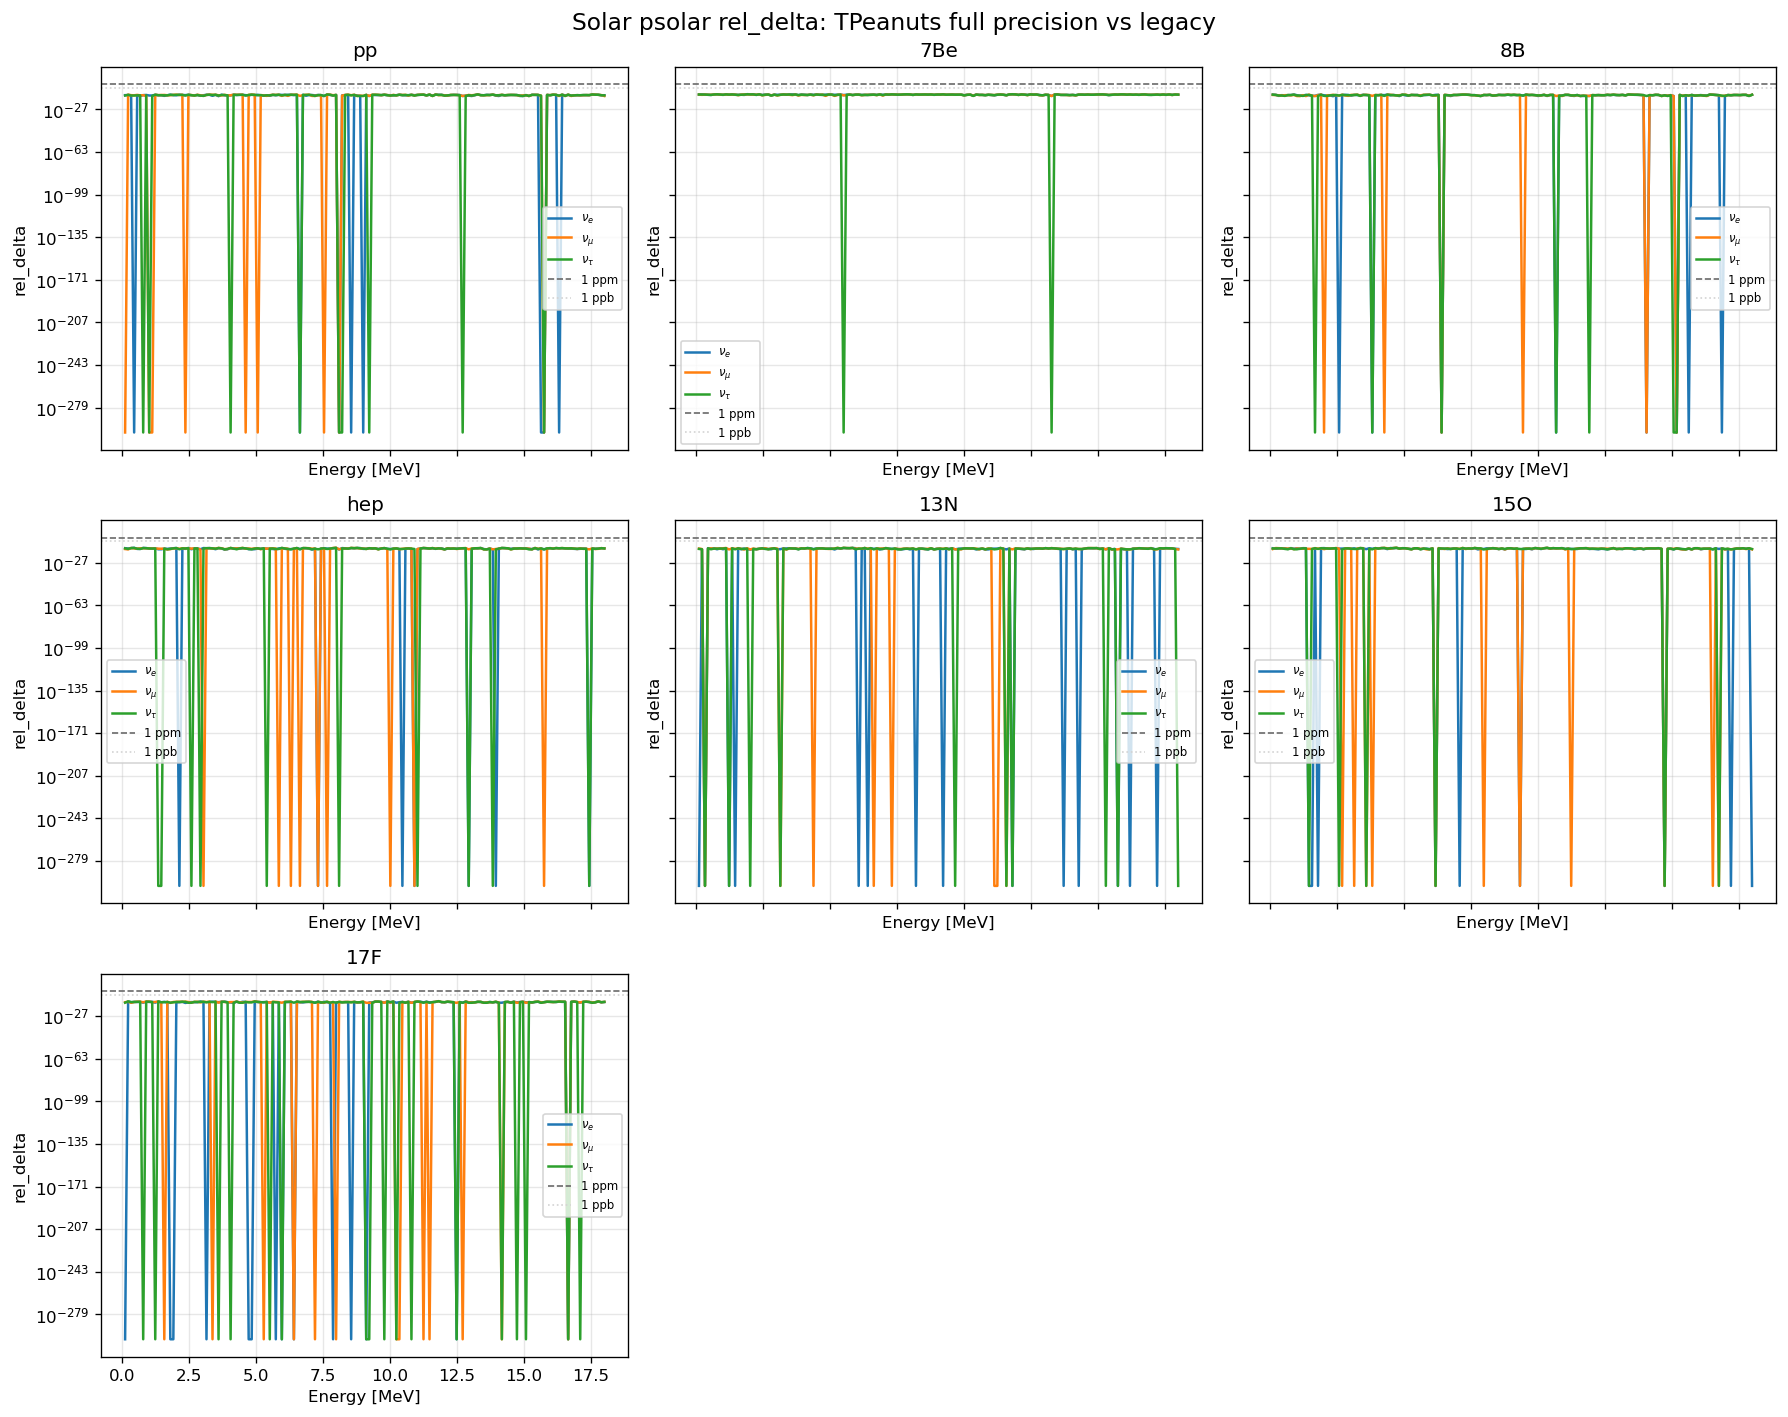

v:\output\validation\legacy\solar\validation_legacy2_solar_rel_delta_sources.png


In [5]:
n = len(SOLAR_SOURCE_ORDER)
ncols, nrows = 3, int(np.ceil(n / 3))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.0 * nrows), sharex=True, sharey=True)
axes_flat = np.asarray(axes).reshape(-1)
for ax, source in zip(axes_flat, SOLAR_SOURCE_ORDER):
    _, rel_delta = abs_rel_delta(scan_by_source[source], legacy_by_source[source])
    for i, (label, color) in enumerate(zip(FLAVOUR_LABELS, FLAVOUR_COLORS)):
        ax.semilogy(to_numpy(SOLAR_ENERGY_GRID_MEV), np.maximum(rel_delta[:, i], 1e-300), color=color, label=label)
    add_tolerance_lines(ax)
    ax.set_title(source)
    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel("rel_delta")
    ax.legend(fontsize=7)
for ax in axes_flat[n:]:
    ax.axis("off")
fig.suptitle("Solar solar_probability_state rel_delta: TPeanuts full precision vs legacy", fontsize=14)
fig.tight_layout()
save_and_show("validation_legacy2_solar_rel_delta_sources.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 4. Precision Mode Diagnostic

The MSW matter potential in the solar Hamiltonian involves the product $V_k = \sqrt{2}\,G_F\,n_e$, which in the legacy Peanuts code was hardcoded to 4 significant digits as a combined prefactor (approximately $3.868\times10^{-7}$ in scaled units), deviating from the full IEEE-754 precision value derived from $G_F$, $N_A$, and $\hbar c$ by a relative factor of $\sim 1.85\times10^{-5}$.

TPeanuts provides a `legacy_precision=True` flag that switches to this same 4-digit prefactor, enabling bit-for-bit reproduction of legacy results. This section compares:

- `full_precision` ($\delta_\text{prefactor} = 0$, correct physics): uses the exact physical constants from CODATA — this is the scientifically correct computation.
- `legacy_precision=True` ($\delta_\text{prefactor} \sim 1.85\times10^{-5}$): exactly reproduces the legacy Peanuts scaled arithmetic.

**Expected Results:**
- In `legacy_precision` mode, both implementations use *identically rounded* prefactors, so the residual discrepancy should be at the level of floating-point round-off only ($\lesssim 10^{-14}$, approaching machine epsilon for `float64`).
- In `full_precision` mode the discrepancy matches the observed $\sim 10^{-4}$ offset from Section 3, confirming that the full discrepancy originates entirely from the prefactor rounding in legacy Peanuts rather than from any algorithmic difference.

### 4.1 Precision-Mode Summary

This cell computes the full-precision and legacy-precision solar probabilities for the selected sources and summarises their absolute and relative differences against the legacy Peanuts reference.


In [6]:
precision_sources = [src for src in SOLAR_PRECISION_SOURCES if src in SOLAR_SOURCE_ORDER]
precision_modes = [("full_precision", False), ("legacy_precision", True)]
precision_energy_np = to_numpy(SOLAR_ENERGY_GRID_MEV)

precision_rows = []
precision_reference_by_source = {}
precision_scan_by_source = {}
for source in precision_sources:
    reference_scan = torch.as_tensor(
        np.stack([legacy_psolar(source, float(energy)) for energy in precision_energy_np]),
        dtype=DTYPE,
        device=DEVICE,
    )
    precision_reference_by_source[source] = reference_scan
    precision_scan_by_source[source] = {}

    for mode_name, mode_flag in precision_modes:
        candidate_scan = solar_probability_state(
            oscillation,
            SOLAR_ENERGY_GRID_MEV,
            solar_profile,
            source,
            legacy_precision=mode_flag,
        )
        precision_scan_by_source[source][mode_name] = candidate_scan
        abs_delta, rel_delta = abs_rel_delta(candidate_scan, reference_scan)
        candidate_np = to_numpy(candidate_scan)
        reference_np = to_numpy(reference_scan)
        for i, energy in enumerate(precision_energy_np):
            for final_name, alpha in FLAVOUR_INDEX.items():
                precision_rows.append(
                    {
                        "medium": "solar",
                        "observable": "psolar_precision_mode",
                        "source": source,
                        "E_MeV": energy,
                        "mode": mode_name,
                        "final_flavour": final_name,
                        "candidate": candidate_np[i, alpha],
                        "reference": reference_np[i, alpha],
                        "abs_delta": abs_delta[i, alpha],
                        "rel_delta": rel_delta[i, alpha],
                        "legacy_precision": mode_flag,
                    }
                )
precision_mode_table = pd.DataFrame(precision_rows)
precision_mode_summary = summarize_validation(precision_mode_table, ["source", "mode"])
display(precision_mode_summary)

,source,mode,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
0,8B,full_precision,480,4.466531e-05,1.051355e-05,1.559127e-05,1.216105e-04,3.353419e-05,4.696992e-05,0.174568,0.330228
2,pp,full_precision,480,4.014979e-05,1.881995e-05,1.860372e-05,1.120659e-04,5.750293e-05,5.583667e-05,0.173891,0.326090
3,pp,legacy_precision,480,1.221245e-15,3.330669e-16,3.437644e-16,3.610839e-15,8.725758e-16,1.038471e-15,0.173891,0.326090
1,8B,legacy_precision,480,1.443290e-15,2.775558e-16,3.214443e-16,3.086313e-15,8.923054e-16,9.617832e-16,0.174568,0.330228


### 4.2 Full Precision vs Legacy Precision Comparison

The diagnostic below compares the legacy-precision compatibility mode against the legacy Peanuts reference over the full configured solar energy grid for the selected production sources. Each row corresponds to one source; columns show the probability values, absolute differences, and relative differences.

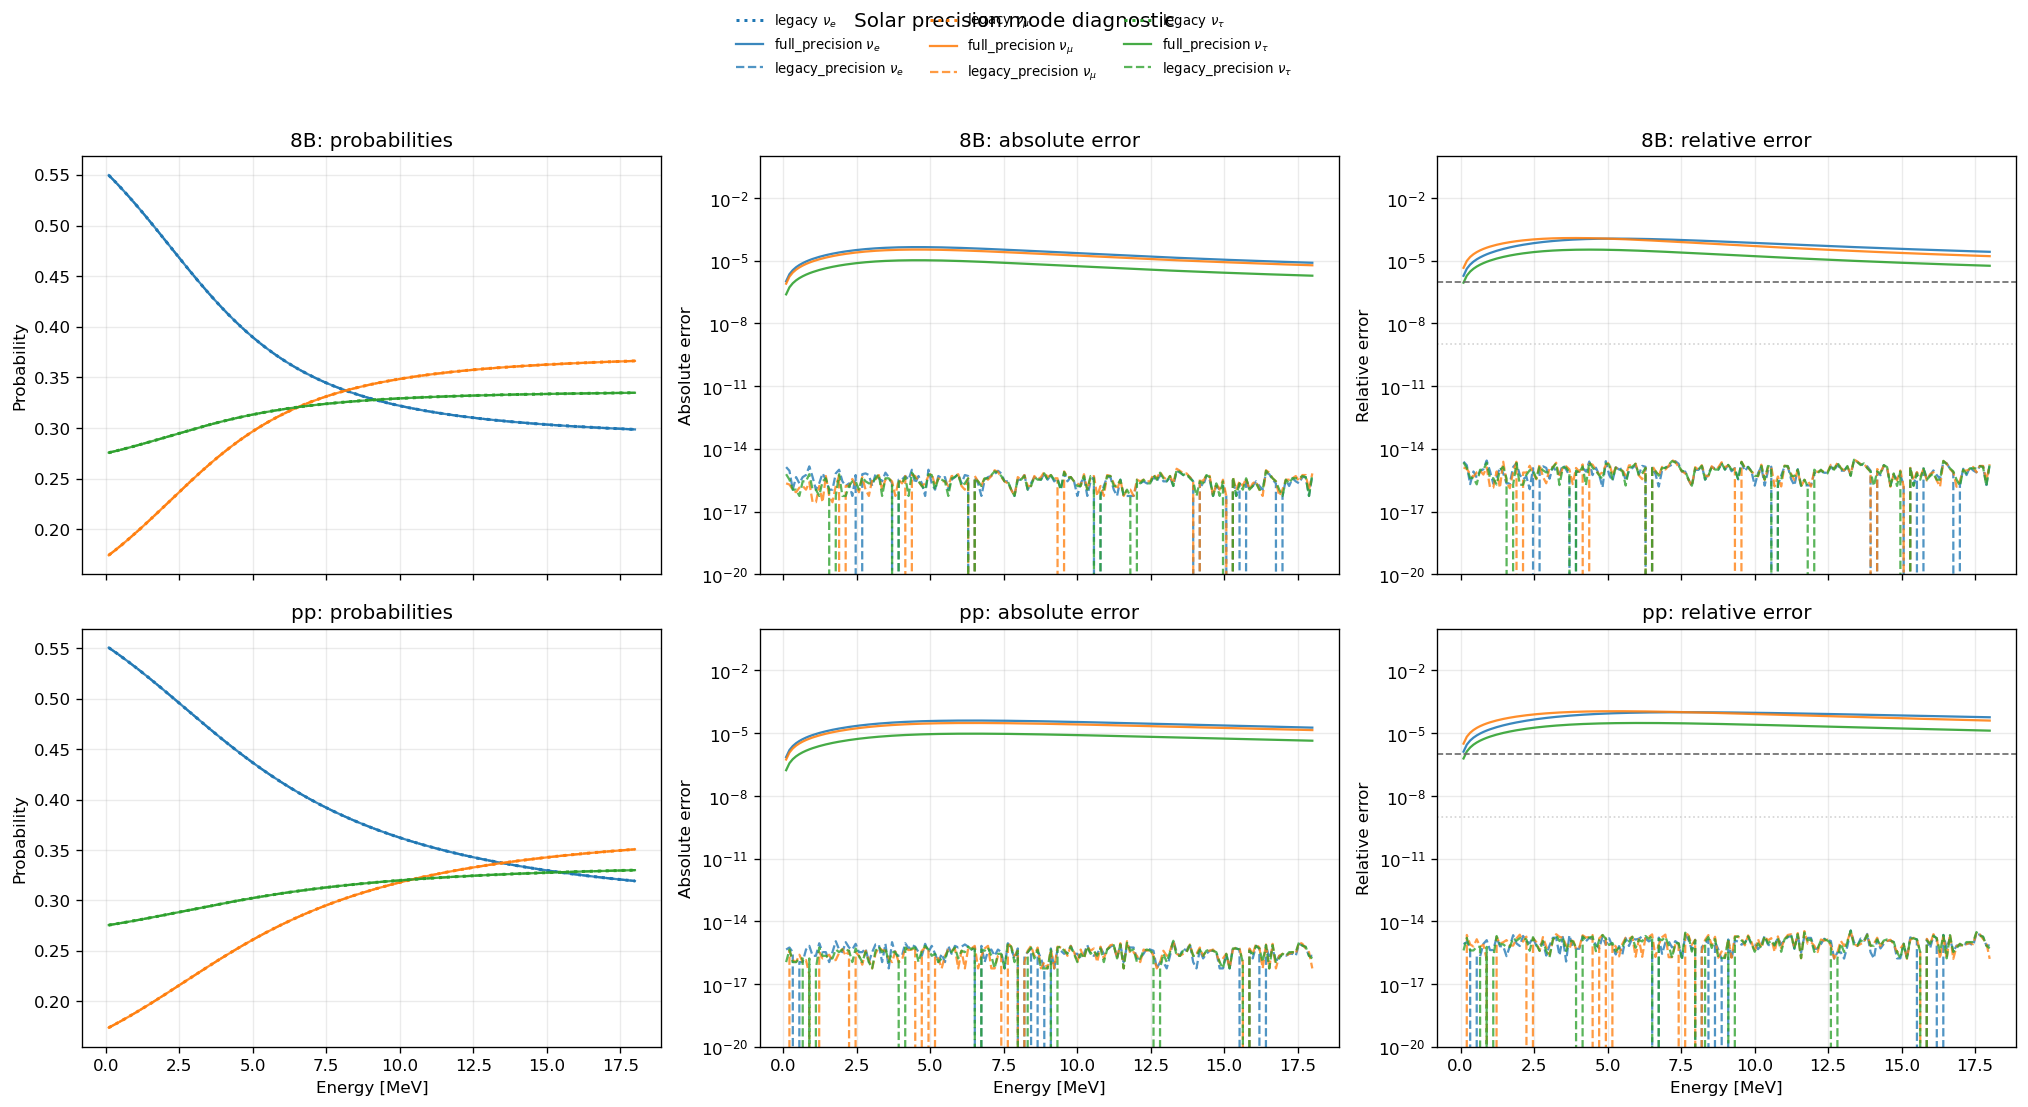

v:\output\validation\legacy\solar\validation_legacy2_solar_precision_modes_energy_scan.png


In [7]:
fig, axes = plt.subplots(
    len(precision_sources),
    3,
    figsize=(17, 4.5 * len(precision_sources)),
    sharex=True,
    squeeze=False,
)
mode_styles = {"full_precision": "-", "legacy_precision": "--"}
mode_alphas = {"full_precision": 0.88, "legacy_precision": 0.78}
value_floor = 1.0e-300

for row, source in enumerate(precision_sources):
    reference_scan = precision_reference_by_source[source]
    reference_np = to_numpy(reference_scan)

    value_ax, abs_ax, rel_ax = axes[row]
    for final_name, alpha in FLAVOUR_INDEX.items():
        label = FLAVOUR_LABELS[alpha]
        color = FLAVOUR_COLORS[alpha]
        value_ax.plot(
            precision_energy_np,
            reference_np[:, alpha],
            color=color,
            linestyle=":",
            linewidth=1.8,
            label=f"legacy {label}",
        )

        for mode_name, _ in precision_modes:
            candidate_scan = precision_scan_by_source[source][mode_name]
            candidate_np = to_numpy(candidate_scan)
            abs_delta, rel_delta = abs_rel_delta(candidate_scan, reference_scan)
            value_ax.plot(
                precision_energy_np,
                candidate_np[:, alpha],
                color=color,
                linestyle=mode_styles[mode_name],
                alpha=mode_alphas[mode_name],
                linewidth=1.35,
                label=f"{mode_name} {label}",
            )
            abs_ax.semilogy(
                precision_energy_np,
                np.maximum(abs_delta[:, alpha], value_floor),
                color=color,
                linestyle=mode_styles[mode_name],
                alpha=mode_alphas[mode_name],
                linewidth=1.35,
                label=f"{mode_name} {label}",
            )
            abs_ax.set_ylim(1e-20,1)
            rel_ax.semilogy(
                precision_energy_np,
                np.maximum(rel_delta[:, alpha], value_floor),
                color=color,
                linestyle=mode_styles[mode_name],
                alpha=mode_alphas[mode_name],
                linewidth=1.35,
                label=f"{mode_name} {label}",
            )
            rel_ax.set_ylim(1e-20,1)

    value_ax.set_title(f"{source}: probabilities")
    abs_ax.set_title(f"{source}: absolute error")
    rel_ax.set_title(f"{source}: relative error")
    value_ax.set_ylabel("Probability")
    abs_ax.set_ylabel("Absolute error")
    rel_ax.set_ylabel("Relative error")
    add_tolerance_lines(rel_ax)

for ax in axes[-1]:
    ax.set_xlabel("Energy [MeV]")
for ax in axes.flat:
    ax.grid(alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=8, frameon=False)
fig.suptitle("Solar precision mode diagnostic", y=1.02)
fig.tight_layout(rect=(0, 0, 1, 0.96))
save_and_show(
    "validation_legacy2_solar_precision_modes_energy_scan.png",
    fig,
    output_dir=OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
)

## 5. Solar Mass-Basis Probability Comparison

For solar neutrino detection experiments (Borexino, SNO, Super-Kamiokande), the relevant intermediate quantity is the mass-eigenstate population after propagation from the solar core to the Earth surface:

$$P_i^\text{solar}(E) \equiv P\!\left(\nu_e(\text{core}) \to \nu_i(\text{surface})\right)$$

The detected $\nu_e$ survival probability is then reconstructed as $P_{ee} = \sum_i |U_{ei}|^2\,P_i^\text{solar}$, where $U$ is evaluated in vacuum at Earth. This factorisation is valid because the vacuum oscillation length between the Sun and Earth ($\sim 10^{11}\,\text{m}$) is much larger than the coherence length; the mass eigenstates propagate independently across the Sun–Earth baseline and the oscillation averages out.

In the fully adiabatic (high-energy) limit, $P_i^\text{solar} \to |\langle \nu_i | \nu_m(0)\rangle|^2$ where $|\nu_m(0)\rangle$ is the matter eigenstate in the solar core. The transition between regimes occurs near the MSW resonance energy

$$E_\text{res} = \frac{\Delta m^2_{21}\cos 2\theta_{12}}{2\sqrt{2}\,G_F\,n_e(r_\text{res})} \approx 1\text{–}2\,\text{MeV}$$

for typical solar-core densities, within the energy range of the pp and $^7$Be sources.

**Expected Results:** The three mass-state probabilities $P_1^\text{solar}$, $P_2^\text{solar}$, $P_3^\text{solar}$ (and their sum, which must equal unity) should agree between implementations to the same $\sim 10^{-4}$ level as the flavour-basis probabilities in Section 4, with the same prefactor origin. The sum $\sum_i P_i^\text{solar}(E) = 1$ serves as a built-in numerical sanity check.

,medium,observable,source,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
0,solar,solar_probability_mass,8B,480,2.997602e-15,7.632783e-17,3.526331e-16,4.173730e-15,8.776519e-16,1.024334e-15,0.022281,0.101805


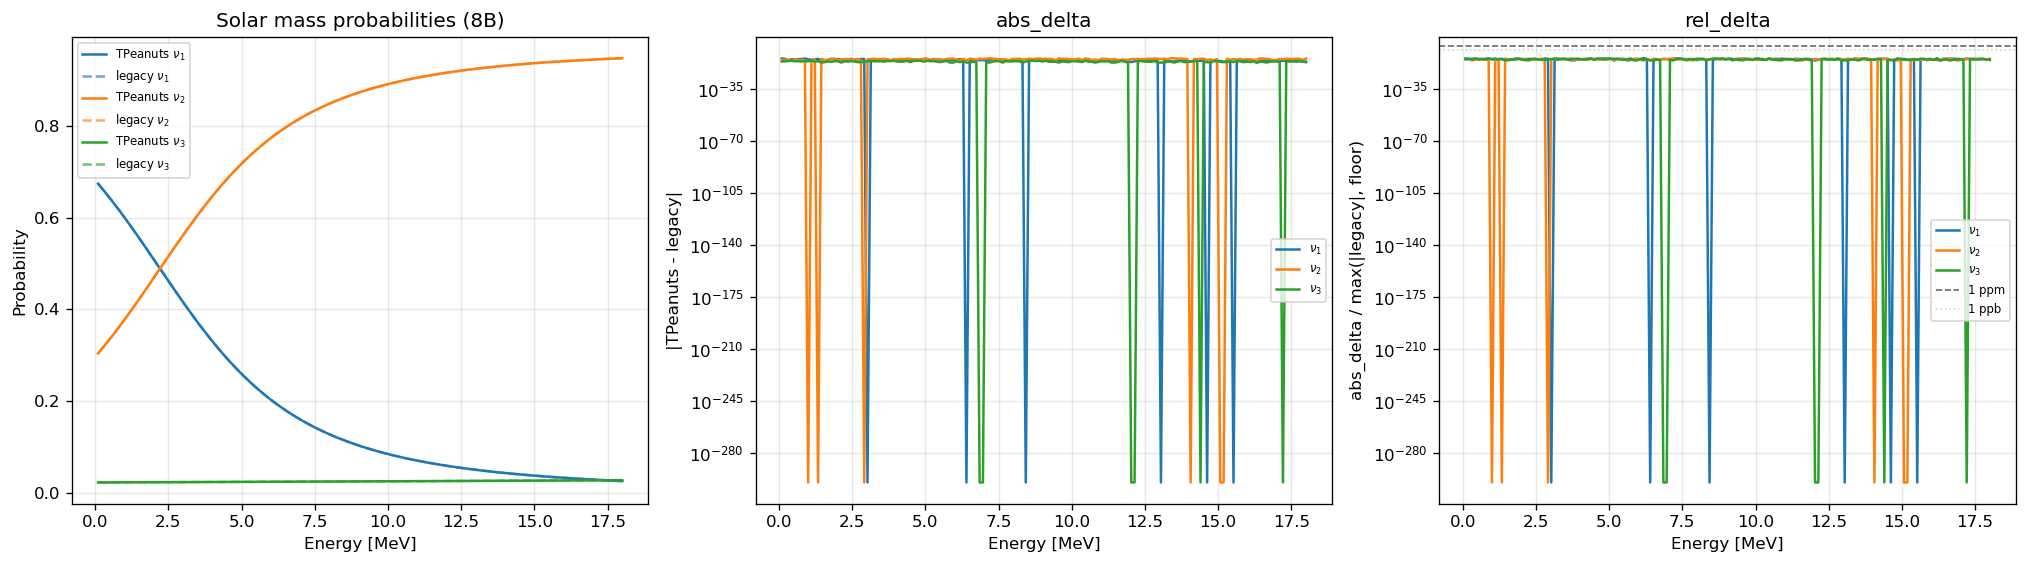

v:\output\validation\legacy\solar\validation_legacy2_solar_mass_probability.png


In [8]:
solar_mass_t = solar_probability_mass(oscillation, SOLAR_ENERGY_GRID_MEV, solar_profile, SOLAR_SOURCE, legacy_precision=LEGACY_PRECISION)
solar_mass_l = np.stack([legacy_solar_module.solar_flux_mass(legacy_pmns_solar.theta12, legacy_pmns_solar.theta13, DM21_EV2, DM3L_EV2, float(E), legacy_model.radius(), legacy_model.density(), legacy_model.fraction(SOLAR_SOURCE)) for E in to_numpy(SOLAR_ENERGY_GRID_MEV)])
abs_mass, rel_mass = abs_rel_delta(solar_mass_t, solar_mass_l)
mass_rows = []
for i, energy in enumerate(to_numpy(SOLAR_ENERGY_GRID_MEV)):
    for mass_idx in range(3):
        mass_rows.append({"medium": "solar", "observable": "solar_probability_mass", "source": SOLAR_SOURCE, "E_MeV": energy, "mass_state": f"nu{mass_idx + 1}", "candidate": to_numpy(solar_mass_t)[i, mass_idx], "reference": solar_mass_l[i, mass_idx], "abs_delta": abs_mass[i, mass_idx], "rel_delta": rel_mass[i, mass_idx]})
solar_mass_table = pd.DataFrame(mass_rows)
display(summarize_validation(solar_mass_table, ["medium", "observable", "source"]))
plot_tripanel(SOLAR_ENERGY_GRID_MEV, solar_mass_t, solar_mass_l, title=f"Solar mass probabilities ({SOLAR_SOURCE})", xlabel="Energy [MeV]", filename="validation_legacy2_solar_mass_probability.png", output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS, labels=[r"$\nu_1$", r"$\nu_2$", r"$\nu_3$"], quantity="probability")

## 6. Export Results

Four CSV files are written for aggregation by `validation_legacy0_summary.ipynb`:

- `validation_legacy2_solar_probability.csv` — per-row results for all sources, energies, and flavours.
- `validation_legacy2_solar_probability_summary.csv` — max/median/mean delta grouped by source.
- `validation_legacy2_solar_precision_modes.csv` - full energy-grid comparison between full precision and legacy precision for the selected solar sources.
- `validation_legacy2_solar_precision_modes_summary.csv` - grouped summary of the precision-mode deltas.
- `validation_legacy2_solar_mass_probability.csv` — mass-eigenstate probabilities for the $^8$B source.

In [9]:
solar_probability_table.to_csv(OUTPUT_DIR / "validation_legacy2_solar_probability.csv", index=False)
solar_probability_summary.to_csv(OUTPUT_DIR / "validation_legacy2_solar_probability_summary.csv", index=False)
#precision_mode_table.to_csv(OUTPUT_DIR / "validation_legacy2_solar_precision_modes.csv", index=False)
#precision_mode_summary.to_csv(OUTPUT_DIR / "validation_legacy2_solar_precision_modes_summary.csv", index=False)
solar_mass_table.to_csv(OUTPUT_DIR / "validation_legacy2_solar_mass_probability.csv", index=False)
print(OUTPUT_DIR)

v:\output\validation\legacy\solar


## 7. Summary

The final table collects the maximum and median relative differences for the solar probability, precision-mode, and mass-basis checks. It separates the ordinary validation controlled by `LEGACY_PRECISION` from the explicit full-vs-legacy precision diagnostic.

In [10]:
summary_tables = [
    ("solar probability", solar_probability_table),
    ("precision modes", precision_mode_table),
    ("solar mass probability", solar_mass_table),
]
summary_rows = []
for label, table in summary_tables:
    summary_rows.append({
        "check": label,
        "rows": len(table),
        "max_abs_delta": table["abs_delta"].max(),
        "max_rel_delta": table["rel_delta"].max(),
        "median_rel_delta": table["rel_delta"].median(),
        "status": status_from_rel(table["rel_delta"].max()),
    })
validation_summary = pd.DataFrame(summary_rows)
display(validation_summary)
print(f"Ordinary solar sections used LEGACY_PRECISION={LEGACY_PRECISION}; Section 4 intentionally compares both precision modes.")

,check,rows,max_abs_delta,max_rel_delta,median_rel_delta,status
0,solar probability,3360,2.775558e-15,5.595689e-15,8.883908e-16,PASS < ppb
1,precision modes,1920,4.466531e-05,1.216105e-04,3.070806e-07,CHECK < 1e-3
2,solar mass probability,480,2.997602e-15,4.173730e-15,8.776519e-16,PASS < ppb


Ordinary solar sections used LEGACY_PRECISION=True; Section 4 intentionally compares both precision modes.
